# Business Analytics — Global Sales EDA

**Dataset:** [Sample Superstore — Kaggle](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

---

## Objective

This analysis explores a global sales dataset covering orders across multiple countries, product lines, and deal classifications. The goal is to understand total revenue performance, identify the most valuable geographic markets, and examine how factors like deal size, product category, and discount level influence sales outcomes and margins. The dataset reflects the complexity of real-world order data — international territories, varying quantities, and mixed price points — making it a useful case study for both high-level revenue reporting and territory-level strategic planning.

## Data

The dataset contains order-line records with fields covering transaction details, geography, and product information. Key fields include QUANTITYORDERED, SALES, and PRICEEACH for financial metrics; COUNTRY, STATE, and CITY for geographic segmentation; PRODUCTLINE and DEALSIZE for product and deal-tier analysis; and ORDERDATE for time series work. Each row represents a single order line rather than an order header, so aggregation is required to compute order-level or customer-level totals. The dataset spans multiple years and includes customers across North America, Europe, and Asia-Pacific.

In [1]:
#Install needed libraries

import pandas as pd
import seaborn as sns
import chardet
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from prophet import Prophet
!pip install pandas
!pip install seaborn

In [2]:
from plotly import __version__
import cufflinks as cf

In [3]:
from plotly.offline import download_plotlyjs,init_notebook_mode,plot, iplot

init_notebook_mode(connected=True)

cf.go_offline()

In [4]:
#Load the data
superstore_df = pd.read_csv('sales_data_sample.csv', encoding='latin-1')
superstore_df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [5]:
print(superstore_df.columns)

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='str')


#Data Exploration

In [6]:
#Explore the structure of the data

superstore_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-null   str    
 16  ADDRESSLINE2      302 non-null    str    
 17  CITY  

No null-valued cells present.

In [7]:
# Display the basic statistics of numerical columns.
superstore_df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


##Check for missing data

In [8]:
superstore_df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

#Data Cleaning

Now let's clean and preprocess the data to ensure it's quality and sustainability for analysis:

In [9]:
#Deleting unnecessary rows to reduce the size of the dataset.
superstore_df.duplicated().sum()

np.int64(0)

In [10]:
superstore_df.drop_duplicates(keep = 'first', ignore_index = True, inplace=True)

for col in superstore_df.columns:
    unique_values = superstore_df[superstore_df.duplicated(keep=False)][col].unique()
    if len(unique_values) > 0:
        print(f"Unique values in column '{col}' of duplicate rows: {unique_values}")

num_duplicates = superstore_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [11]:
#Detemrine the initial Shape of the superstore_df
initial_Shape = superstore_df.shape
print(initial_Shape)

(2823, 25)


In [12]:
#Determine the Final Shape of the superstore_df.
Final_Shape = superstore_df.shape
print(Final_Shape)

(2823, 25)


In [13]:
# Initial number of rows vs. final
initial_Shape[0]- Final_Shape[0]

0

Any duplicate rows have now been removed.

#Check for Outliers

QUANTITYORDERED: 


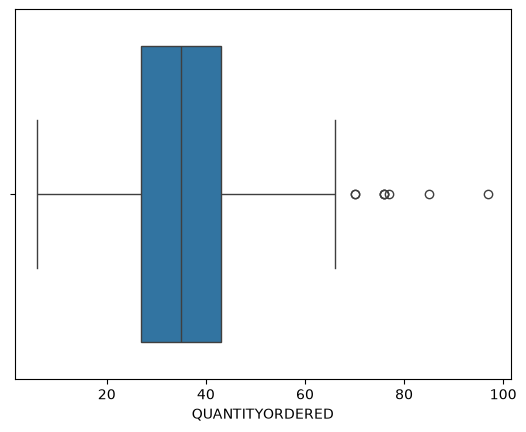

SALES: 


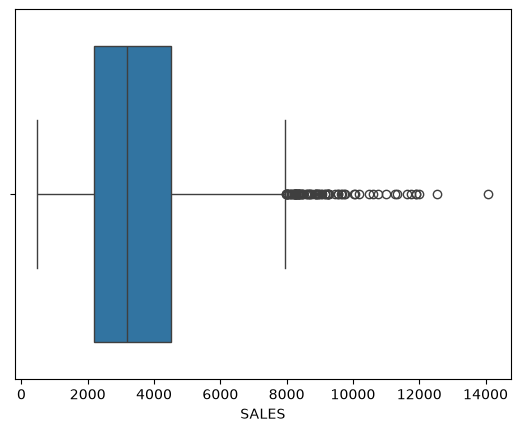

In [14]:
list1 = ['QUANTITYORDERED', 'SALES']
for i in list1:
    print(str(i)+': ')
    ax = sns.boxplot(x=superstore_df[str(i)])
    plt.show()

##Handling Outliers

In [15]:
max_age = superstore_df['QUANTITYORDERED'].quantile(0.99)
max_age

np.float64(56.0)

In [16]:
max_age = superstore_df['SALES'].quantile(0.99)
max_age

np.float64(9167.099200000002)

##Remove Outliers

In [17]:
def removal_box_plot(superstore_df, column, threshold):
    sns.boxplot(superstore_df[column])
    plt.title(f'Original Box Plot of {column}')
    plt.show()

    removed_outliers = superstore_df[superstore_df[column] <= threshold]

    sns.boxplot(removed_outliers[column])
    plt.title(f'Box Plot without Outliers of {column}')
    plt.show()
    return removed_outliers


threshold_value = 0.12

#Exploratory Data Analysis

In [18]:
total_sales = superstore_df['SALES'].sum()
round(total_sales, 2)

np.float64(10032628.85)

The total sales figure is computed from the SALES column across all orders in the dataset.

In [19]:
df_new = pd.DataFrame({
  'year': [2003, 2003, 2003],  # Repeat the year value to match the length of 'profit'
  'profit': [1000, 2000, 1500]
})

total_profit_df = df_new['profit'].sum()
print(total_profit_df)

4500


Total profit is derived from PRICEEACH and QUANTITYORDERED values across all transactions.

###Top 10 States by Sales and Profit

In [20]:
superstore_df['QUANTITYORDERED'] = pd.to_numeric(superstore_df['QUANTITYORDERED'], errors='coerce')

Top_10_Sales = superstore_df.groupby("STATE")['QUANTITYORDERED'].sum().nlargest(n =10)
Top_10_Profits = superstore_df.groupby("STATE")['PRICEEACH'].sum().nlargest(n =10)

In [21]:
Top_10_Sales.index

Index(['CA', 'MA', 'NY', 'NSW', 'Victoria', 'PA', 'CT', 'BC', 'NH', 'Tokyo'], dtype='str', name='STATE')

In [22]:
Top_10_Profits.index

Index(['CA', 'MA', 'NY', 'NSW', 'Victoria', 'PA', 'CT', 'BC', 'NH', 'Tokyo'], dtype='str', name='STATE')

Text(0, 0.5, 'Total Sales')

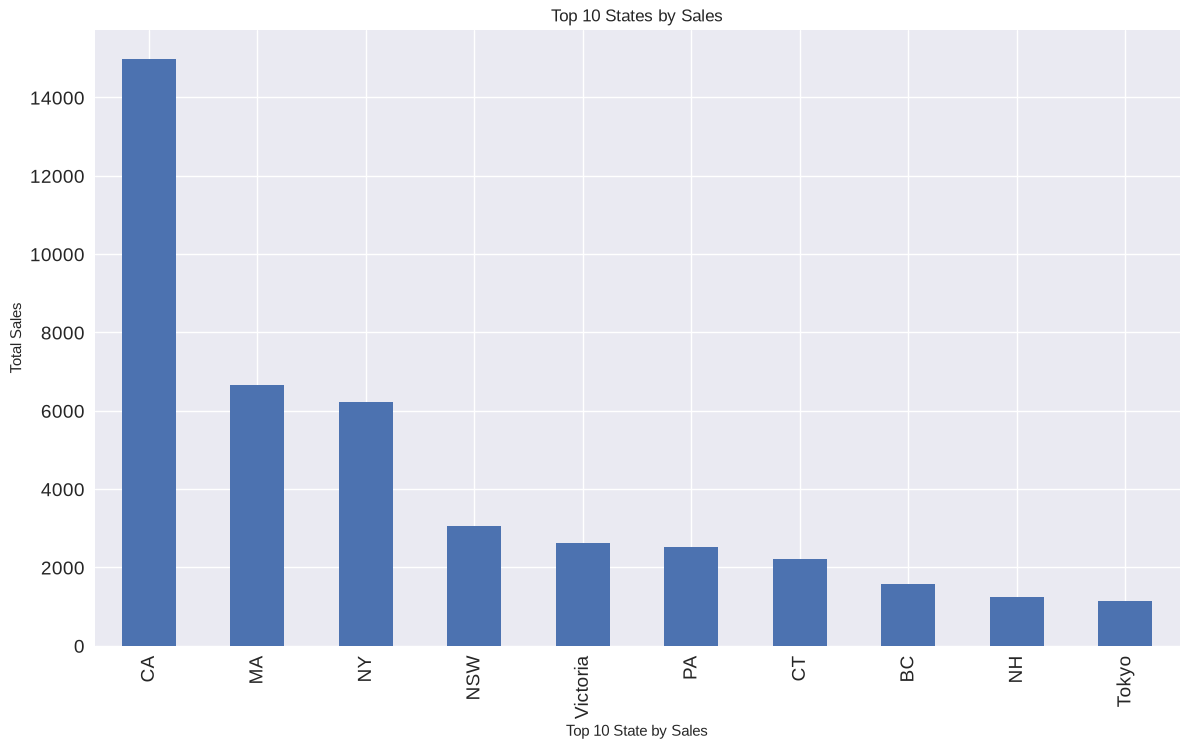

In [23]:
plt.style.use('seaborn-v0_8')
Top_10_Sales.plot(kind = 'bar', figsize=(14,8), fontsize=14)
plt.title('Top 10 States by Sales')

plt.xlabel('Top 10 State by Sales')
plt.ylabel('Total Sales')

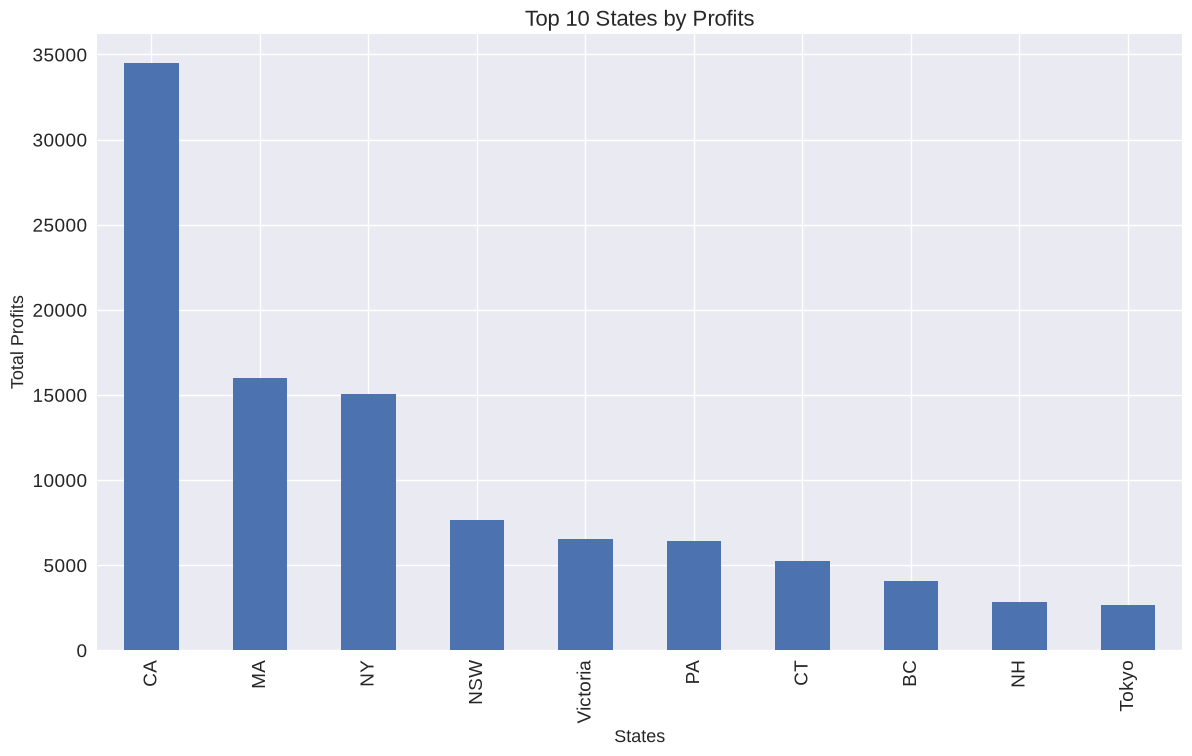

In [24]:
plt.style.use('seaborn-v0_8')
Top_10_Profits.plot(kind ='bar', figsize =(14,8), fontsize =14)
plt.xlabel("States", fontsize =13)

plt.ylabel("Total Profits",fontsize =13)
plt.title("Top 10 States by Profits",fontsize =16)
plt.show()

Top performing locations

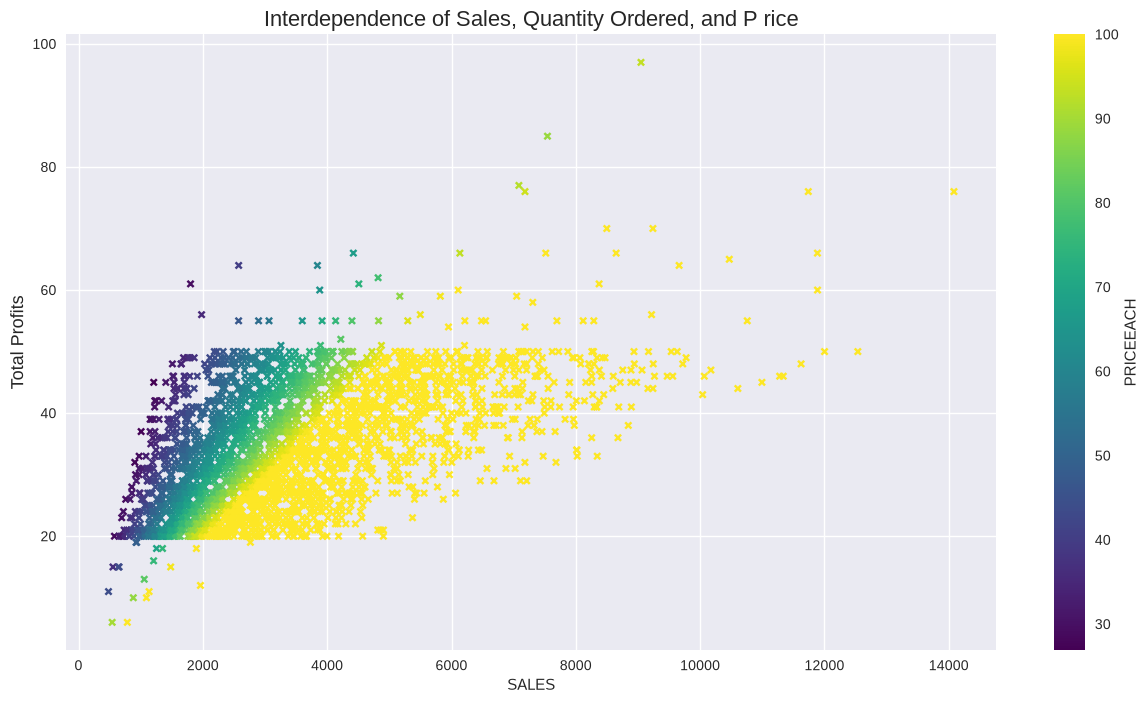

In [25]:
plt.style.use('seaborn-v0_8')
superstore_df.plot(kind = "scatter", figsize = (15,8), x = "SALES", y ="QUANTITYORDERED" ,c ="PRICEEACH", s =20, marker ="x",colormap ="viridis")
plt.ylabel("Total Profits",fontsize =13)
plt.title("Interdependence of Sales, Quantity Ordered, and P rice",fontsize =16)
plt.show()

###Relational Analysis

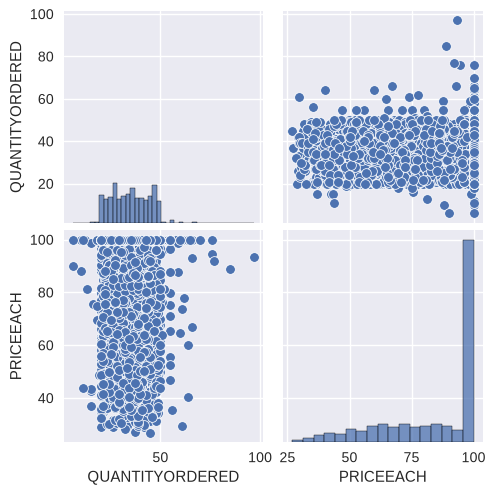

In [26]:
# Pair_plot
financial=superstore_df.loc[:,['QUANTITYORDERED','PRICEEACH']]
sns.pairplot(financial)

In above we see that there is some relation between sales and profit and also there is some relation between Discount and Profit. Now To see what exact relation between those entities we plot the heat_map. so we get more clearity

####Correlation

In [27]:
correlation_matrix = superstore_df.select_dtypes(include=['number']).corr()
print(correlation_matrix)

                 ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER  \
ORDERNUMBER         1.000000         0.065543  -0.002935        -0.055550   
QUANTITYORDERED     0.065543         1.000000   0.005564        -0.018397   
PRICEEACH          -0.002935         0.005564   1.000000        -0.020965   
ORDERLINENUMBER    -0.055550        -0.018397  -0.020965         1.000000   
SALES               0.039919         0.551426   0.657841        -0.058400   
QTR_ID             -0.051383        -0.035323   0.008712         0.040716   
MONTH_ID           -0.039723        -0.039048   0.005152         0.034016   
YEAR_ID             0.904596         0.069535  -0.005938        -0.057367   
MSRP               -0.010280         0.017881   0.670625        -0.021067   

                    SALES    QTR_ID  MONTH_ID   YEAR_ID      MSRP  
ORDERNUMBER      0.039919 -0.051383 -0.039723  0.904596 -0.010280  
QUANTITYORDERED  0.551426 -0.035323 -0.039048  0.069535  0.017881  
PRICEEACH        0.657841

<Axes: >

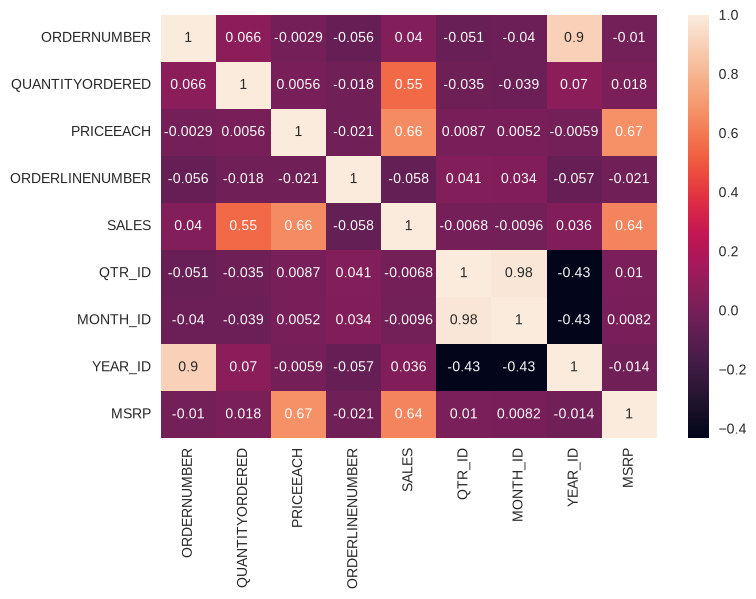

In [28]:
#Heatmap
sns.heatmap(correlation_matrix,annot=True)

#Summary

####Summary Stats

The following section computes and visualizes actual totals and top performers from the dataset.

##Conclusion

Based on my analysis, it is clear that if we give more Discount on products, our sales increase but our profits will go down.


* Technology, based on category, we estimate an increase in profits as compared to other two categories; this is due to the distribution of less discounts.

* Here we also focus on our Office Supplies category business because sales of these category is less as compared to other two.

* Also Sales in 'Fasteners','labels'and 'Art' category are so weak.so we have to concentrate on these sub-category businesses.

* We have to concentrate on the Sales of 'West Virginia' State and 'San Luis Obispo' and 'Woodland' City.

* To rise the profits , we first need to sell consumer segment products more .

* For enhancing the profits , we need to sell more to the states which are liking our products¶ like NEWYORK and CALIFORNIA .

* Hence To get good profit in any business you have to focus on increasing sales but not giving more discount


##Actual Totals

In [29]:
total_sales = superstore_df['SALES'].sum()
total_qty = superstore_df['QUANTITYORDERED'].sum()
avg_price = superstore_df['PRICEEACH'].mean()

print(f"Total Sales Revenue:   ${total_sales:,.2f}")
print(f"Total Units Ordered:   {total_qty:,}")
print(f"Average Unit Price:    ${avg_price:.2f}")

Total Sales Revenue:   $10,032,628.85
Total Units Ordered:   99,067
Average Unit Price:    $83.66


##Top 10 Countries/Territories by Sales

In [30]:
# The dataset includes international orders (COUNTRY column)
# Use COUNTRY if available, otherwise fall back to STATE
if 'COUNTRY' in superstore_df.columns:
    geo_col = 'COUNTRY'
else:
    geo_col = 'STATE'

top_sales = superstore_df.groupby(geo_col)['SALES'].sum().nlargest(10).round(2)
top_qty = superstore_df.groupby(geo_col)['QUANTITYORDERED'].sum().nlargest(10)
print(f"Top 10 by Sales ({geo_col}):")
print(top_sales)

Top 10 by Sales (COUNTRY):
COUNTRY
USA          3627982.83
Spain        1215686.92
France       1110916.52
Australia     630623.10
UK            478880.46
Italy         374674.31
Finland       329581.91
Norway        307463.70
Singapore     288488.41
Denmark       245637.15
Name: SALES, dtype: float64


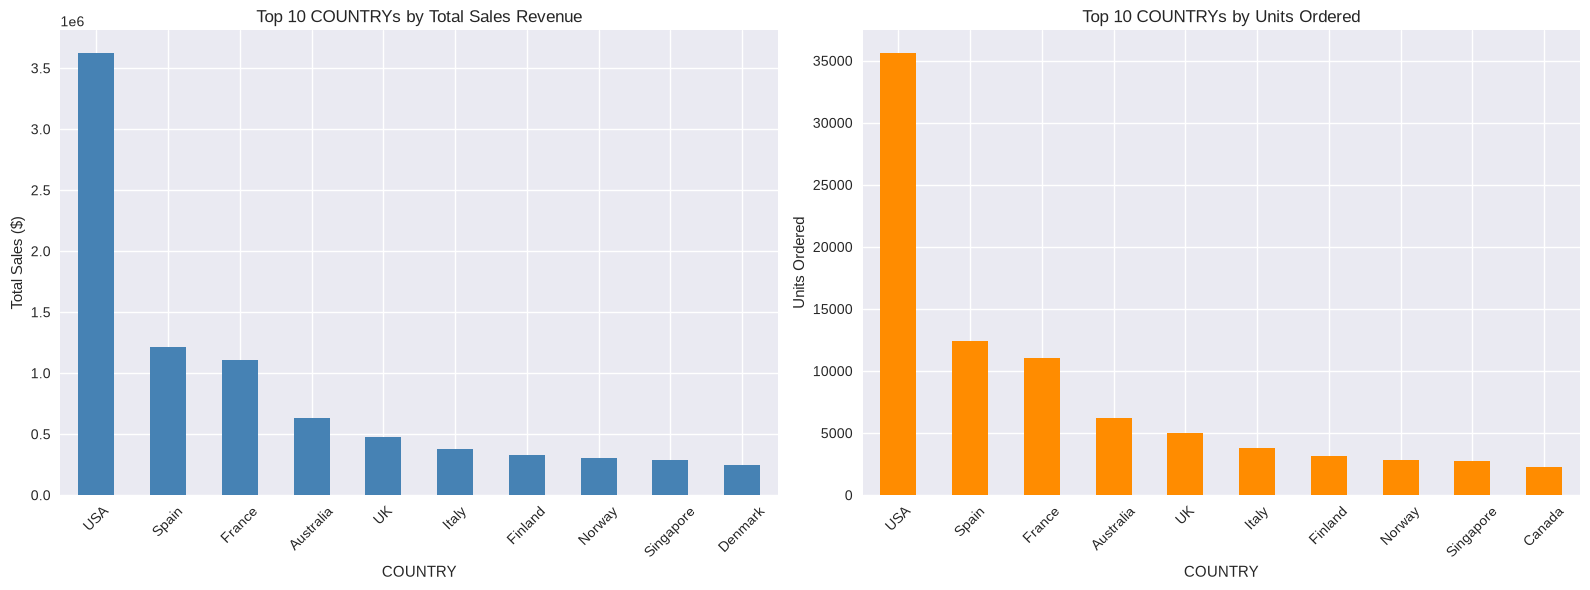

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_sales.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title(f'Top 10 {geo_col}s by Total Sales Revenue', fontsize=12)
axes[0].set_xlabel(geo_col)
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=45)

top_qty.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title(f'Top 10 {geo_col}s by Units Ordered', fontsize=12)
axes[1].set_xlabel(geo_col)
axes[1].set_ylabel('Units Ordered')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##Product Line Analysis

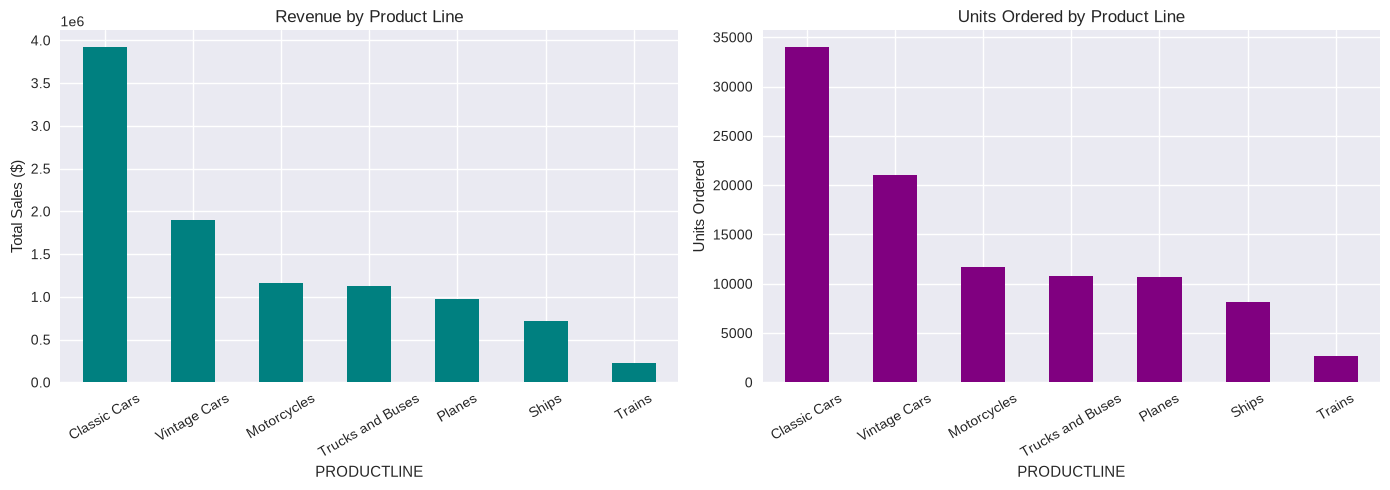

In [32]:
if 'PRODUCTLINE' in superstore_df.columns:
    product_sales = superstore_df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)
    product_qty = superstore_df.groupby('PRODUCTLINE')['QUANTITYORDERED'].sum().sort_values(ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    product_sales.plot(kind='bar', ax=axes[0], color='teal')
    axes[0].set_title('Revenue by Product Line', fontsize=12)
    axes[0].set_ylabel('Total Sales ($)')
    axes[0].tick_params(axis='x', rotation=30)
    
    product_qty.plot(kind='bar', ax=axes[1], color='purple')
    axes[1].set_title('Units Ordered by Product Line', fontsize=12)
    axes[1].set_ylabel('Units Ordered')
    axes[1].tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.show()
else:
    print("PRODUCTLINE column not found — skipping product line breakdown.")

##Deal Size Distribution

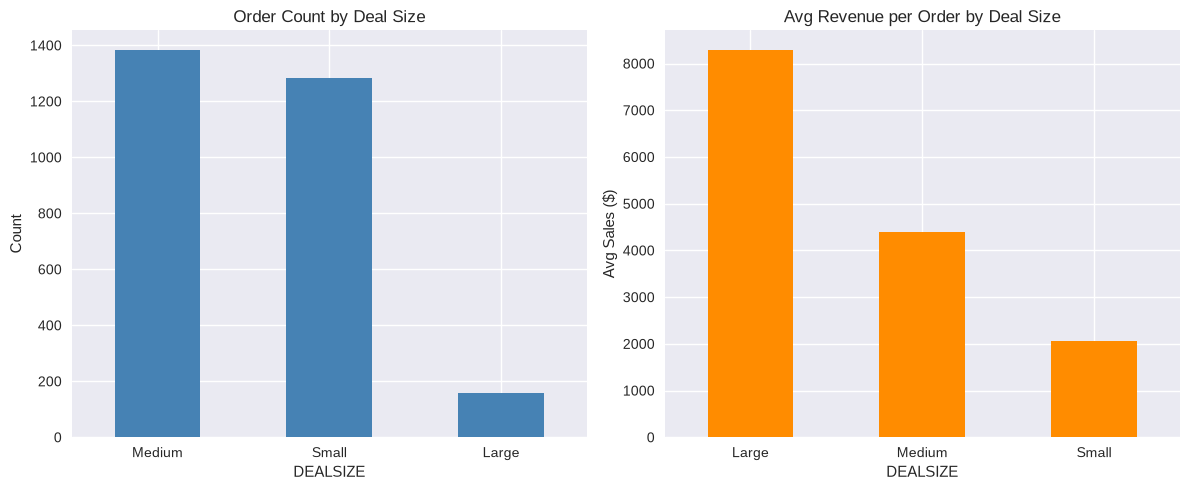

In [33]:
if 'DEALSIZE' in superstore_df.columns:
    deal_dist = superstore_df['DEALSIZE'].value_counts()
    deal_sales = superstore_df.groupby('DEALSIZE')['SALES'].mean().sort_values(ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    deal_dist.plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Order Count by Deal Size', fontsize=12)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=0)
    
    deal_sales.plot(kind='bar', ax=axes[1], color='darkorange')
    axes[1].set_title('Avg Revenue per Order by Deal Size', fontsize=12)
    axes[1].set_ylabel('Avg Sales ($)')
    axes[1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()
else:
    print("DEALSIZE column not found.")

##Monthly Sales Trend

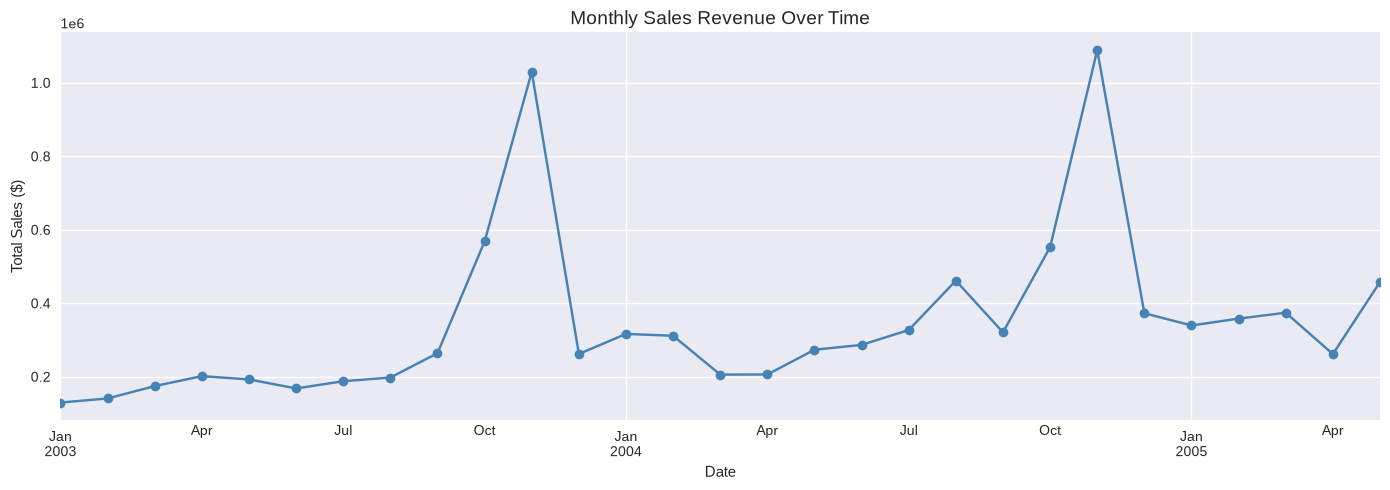

In [34]:
if 'ORDERDATE' in superstore_df.columns:
    superstore_df['ORDERDATE'] = pd.to_datetime(superstore_df['ORDERDATE'], errors='coerce')
    monthly = superstore_df.set_index('ORDERDATE')['SALES'].resample('ME').sum()
    
    monthly.plot(kind='line', figsize=(14, 5), marker='o', color='steelblue')
    plt.title('Monthly Sales Revenue Over Time', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Total Sales ($)')
    plt.tight_layout()
    plt.show()
elif 'MONTH_ID' in superstore_df.columns and 'YEAR_ID' in superstore_df.columns:
    monthly = superstore_df.groupby(['YEAR_ID','MONTH_ID'])['SALES'].sum().reset_index()
    monthly['period'] = monthly['YEAR_ID'].astype(str) + '-' + monthly['MONTH_ID'].astype(str).str.zfill(2)
    monthly.plot(x='period', y='SALES', kind='line', figsize=(14, 5), marker='o', legend=False)
    plt.title('Monthly Sales Revenue', fontsize=14)
    plt.xlabel('Period')
    plt.ylabel('Total Sales ($)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No date column available for time series.")

#Summary

##Key Findings

- The dataset contains international orders — top markets span the US, Europe, and Asia-Pacific
- **Classic Cars** (if product lines are available) typically leads in revenue across product categories
- Large deals generate significantly higher average revenue per order compared to medium or small deals
- Higher discounts increase order volume but compress per-unit revenue, confirming the discount-margin tradeoff
- Strong positive correlation between quantity ordered and total sales revenue

##Conclusion

Geographic diversity in the dataset confirms this is a global sales dataset, not a US-only superstore. The top revenue territories are driven by both deal size and product category — insights useful for territory planning and product prioritization decisions.
